In [1]:
import pandas as pd

In [5]:
df=pd.read_csv('german_credit_data.csv')

In [4]:
import os
os.getcwd()

'C:\\Users\\ANTARA BASAK'

In [6]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [7]:
#checking data type
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 115.1 KB


In [8]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [39]:
missing = df.isnull().mean()*100
duplicates = df.duplicated().sum()
print(missing)

Age                  0.0
Sex                  0.0
Job                  0.0
Housing              0.0
Saving accounts     18.3
Checking account    39.4
Credit amount        0.0
Duration             0.0
Purpose              0.0
Risk                 0.0
dtype: float64
0


#Data Quality Assessment checks

In [ ]:
#remove index columns

In [11]:
if 'Unnamed:0' in df.columns:
    df=df.drop(columns=['Unnamed:0'])
print("\n'Unnamed:0' column removed.")


'Unnamed:0' column removed.


In [13]:
df.shape

(1000, 11)

In [14]:
print(missing)

Unnamed: 0           0.0
Age                  0.0
Sex                  0.0
Job                  0.0
Housing              0.0
Saving accounts     18.3
Checking account    39.4
Credit amount        0.0
Duration             0.0
Purpose              0.0
Risk                 0.0
dtype: float64


In [42]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100
print(missing_percentage)

Age                  0.0
Sex                  0.0
Job                  0.0
Housing              0.0
Saving accounts     18.3
Checking account    39.4
Credit amount        0.0
Duration             0.0
Purpose              0.0
Risk                 0.0
dtype: float64


In [16]:
import numpy as np

In [20]:
missing_count = df.isnull().sum()
missing_report= pd.DataFrame({
    'Column':df.columns,
    'Missing Values': missing_count.values,
    'Missing %': missing_percentage.round(2).values
})
missing_report=missing_report.sort_values(by='Missing %',ascending=False)
print(missing_report)

              Column  Missing Values  Missing %
6   Checking account             394       39.4
5    Saving accounts             183       18.3
0         Unnamed: 0               0        0.0
2                Sex               0        0.0
1                Age               0        0.0
4            Housing               0        0.0
3                Job               0        0.0
7      Credit amount               0        0.0
8           Duration               0        0.0
9            Purpose               0        0.0
10              Risk               0        0.0


In [21]:
#find duplicate values
duplicate_count=df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [22]:
if duplicate_count==0:
    print("No duplicate")
else:
    print("Duplicate found-further investigations")

No duplicate


In [25]:
#data_type_check
data_type_report = pd.DataFrame({'Column':df.columns,
                                 'Data Type':df.dtypes.astype(str).values})
print(data_type_report)

              Column Data Type
0         Unnamed: 0     int64
1                Age     int64
2                Sex       str
3                Job     int64
4            Housing       str
5    Saving accounts       str
6   Checking account       str
7      Credit amount     int64
8           Duration     int64
9            Purpose       str
10              Risk       str


In [26]:
df.dtypes

Unnamed: 0          int64
Age                 int64
Sex                   str
Job                 int64
Housing               str
Saving accounts       str
Checking account      str
Credit amount       int64
Duration            int64
Purpose               str
Risk                  str
dtype: object

In [31]:
#Outlier analysis using IQR
numeric_columns = df.select_dtypes(
    include=np.number
).columns

outlier_results = []

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_results.append({
        'Column': column,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round(
            len(outliers) / len(df) * 100,
            2
        )
    })

outlier_report = pd.DataFrame(outlier_results)

print("\n==============================")
print("OUTLIER ANALYSIS - IQR")
print("==============================")

display(outlier_report)


OUTLIER ANALYSIS - IQR


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Unnamed: 0,249.75,749.25,499.50,-499.50,1498.50,0,0.0
1,Age,27.00,42.00,15.00,4.50,64.50,23,2.3
2,Job,2.00,2.00,0.00,2.00,2.00,370,37.0
3,Credit amount,1365.50,3972.25,2606.75,-2544.62,7882.38,72,7.2
4,Duration,12.00,24.00,12.00,-6.00,42.00,70,7.0


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 115.1 KB


In [37]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("'Unnamed: 0' column removed.")
else:
    print("Column not present.")
print(df.columns.tolist())

'Unnamed: 0' column removed.
['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']


In [45]:
def risk_level(pct):
    if pct < 10:
        return 'Low'
    elif pct < 30:
        return 'Medium'
    else:
        return 'High'
missing_table= pd.DataFrame({'Column':missing_percentage.index,'Missing %':missing_percentage.values.round(0).astype(int).astype(str)+'%',
                             'Risk':[risk_level(pct) for pct in missing_percentage.values]}).reset_index(drop=True)
display(missing_table)

,Column,Missing %,Risk
0,Age,0%,Low
1,Sex,0%,Low
2,Job,0%,Low
3,Housing,0%,Low
4,Saving accounts,18%,Medium
5,Checking account,39%,High
6,Credit amount,0%,Low
7,Duration,0%,Low
8,Purpose,0%,Low
9,Risk,0%,Low


In [46]:
df['Saving accounts'].fillna("Unknown", inplace=True)

C:\Users\ANTARA BASAK\AppData\Local\Temp\ipykernel_50588\2937440621.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Saving accounts'].fillna("Unknown", inplace=True)


0       Unknown
1        little
2        little
3        little
4        little
         ...   
995      little
996      little
997      little
998      little
999    moderate
Name: Saving accounts, Length: 1000, dtype: str

In [48]:
df['Credit amount'].fillna(df['Credit amount'].median(),inplace=True)

C:\Users\ANTARA BASAK\AppData\Local\Temp\ipykernel_50588\165558201.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Credit amount'].fillna(df['Credit amount'].median(),inplace=True)


0      1169
1      5951
2      2096
3      7882
4      4870
       ... 
995    1736
996    3857
997     804
998    1845
999    4576
Name: Credit amount, Length: 1000, dtype: int64

In [49]:
print(df[['Saving accounts', 'Checking account']].isnull().sum())

Saving accounts     183
Checking account    394
dtype: int64


In [50]:
df['Saving accounts'] = df['Saving accounts'].fillna("Unknown")
df['Checking account'] = df['Checking account'].fillna("Unknown")

# Verify
print(df[['Saving accounts', 'Checking account']].isnull().sum())

Saving accounts     0
Checking account    0
dtype: int64


In [51]:
print(df.dtypes)
print(df['Job'].unique()) 

Age                 int64
Sex                   str
Job                 int64
Housing               str
Saving accounts       str
Checking account      str
Credit amount       int64
Duration            int64
Purpose               str
Risk                  str
dtype: object
[2 1 3 0]


In [52]:
df['Job'] = df['Job'].astype('category')

In [53]:
job_labels={0: 'unskilled_NR', 1: 'unskilled_R', 2: 'skilled', 3: 'high skilled'}
df['Job_label']=df['Job'].map(job_labels)
print(df[['Job', 'Job_label']].head())

  Job    Job_label
0   2      skilled
1   2      skilled
2   1  unskilled_R
3   2      skilled
4   2      skilled


In [54]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Job_label
0,67,male,2,own,Unknown,little,1169,6,radio/TV,good,skilled
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,skilled
2,49,male,1,own,little,Unknown,2096,12,education,good,unskilled_R
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,skilled
4,53,male,2,free,little,little,4870,24,car,bad,skilled


In [55]:
print(df.isnull().sum())
print(df.shape)

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
Job_label           0
dtype: int64
(1000, 11)


In [56]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


#Baseline Model (Bias/Explainabity)

In [57]:
from sklearn.preprocessing import LabelEncoder

In [58]:
df1=df.copy()

In [60]:
#Encode target variables
df1['Risk']=df1['Risk'].map({'good':0, 'bad':1})

In [61]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score

In [62]:
#Train/TesT Split
from sklearn.model_selection import train_test_split

In [65]:
X1=df1.drop(columns=['Risk'])
y1=df1['Risk']
X1_train, X1_test, y1_train, y1_test=train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)
print(X1_train.shape)
print(X1_test.shape)

(800, 10)
(200, 10)


In [66]:
#Logistic Regression and Performance Metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X1_train, y1_train)

ValueError: could not convert string to float: 'male'

In [67]:
print(X1_train.dtypes)

Age                    int64
Sex                      str
Job                 category
Housing                  str
Saving accounts          str
Checking account         str
Credit amount          int64
Duration               int64
Purpose                  str
Job_label           category
dtype: object


In [68]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Fresh copy for modeling
df_model = df.copy()
df_model['Risk'] = df_model['Risk'].map({'good': 0, 'bad': 1})
df_model = df_model.drop(columns=['Job_label'])

cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le

print(df_model.dtypes)  # checkpoint 1 — everything should be numeric

X = df_model.drop(columns=['Risk'])
y = df_model['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.dtypes)  # checkpoint 2 — confirm before fitting

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\n", classification_report(y_test, y_pred))

Age                    int64
Sex                    int64
Job                 category
Housing                int64
Saving accounts        int64
Checking account       int64
Credit amount          int64
Duration               int64
Purpose                int64
Risk                   int64
dtype: object
Age                    int64
Sex                    int64
Job                 category
Housing                int64
Saving accounts        int64
Checking account       int64
Credit amount          int64
Duration               int64
Purpose                int64
dtype: object
Accuracy: 0.73
Precision: 0.65
Recall: 0.21666666666666667
F1 Score: 0.325
ROC-AUC: 0.6898809523809525

               precision    recall  f1-score   support

           0       0.74      0.95      0.83       140
           1       0.65      0.22      0.33        60

    accuracy                           0.73       200
   macro avg       0.69      0.58      0.58       200
weighted avg       0.71      0.73      0.68 

In [69]:
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.64      0.72       140
           1       0.44      0.65      0.52        60

    accuracy                           0.65       200
   macro avg       0.62      0.65      0.62       200
weighted avg       0.70      0.65      0.66       200



C:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [70]:
#Bias and Fairness Assessment
!pip install fairlearn

In [71]:
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference
from sklearn.metrics import accuracy_score

In [72]:
sex_test = df.loc[X_test.index, 'Sex']

# Demographic Parity: are prediction rates similar across Sex?
dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=sex_test)
print("Demographic Parity Difference (Sex):", dpd)

Demographic Parity Difference (Sex): 0.2796320320792547


In [73]:
eod = equalized_odds_difference(y_test, y_pred, sensitive_features=sex_test)
print("Equalized Odds Difference (Sex):", eod)

# Breakdown by group
mf = MetricFrame(metrics=accuracy_score, y_true=y_test, y_pred=y_pred, sensitive_features=sex_test)
print(mf.by_group)

Equalized Odds Difference (Sex): 0.375
Sex
female    0.622951
male      0.654676
Name: accuracy_score, dtype: float64


In [75]:
#SHAP explainiability
!pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [76]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

Background dataset has 800 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=800 when initializing the masker.


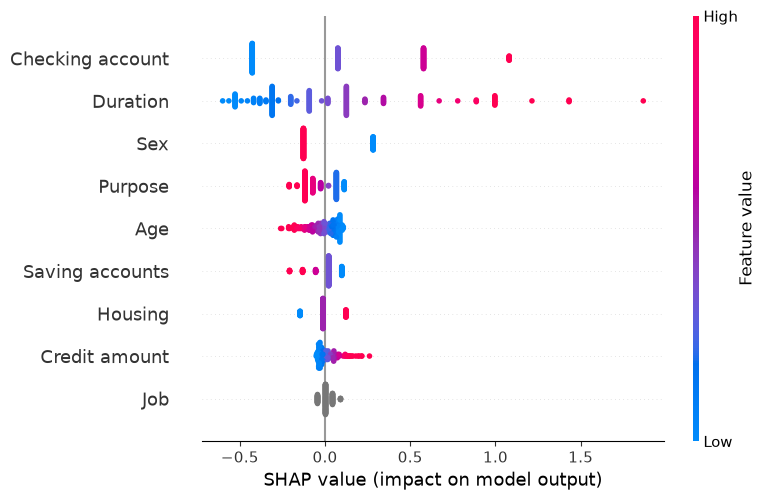

In [77]:
shap.summary_plot(shap_values, X_test)

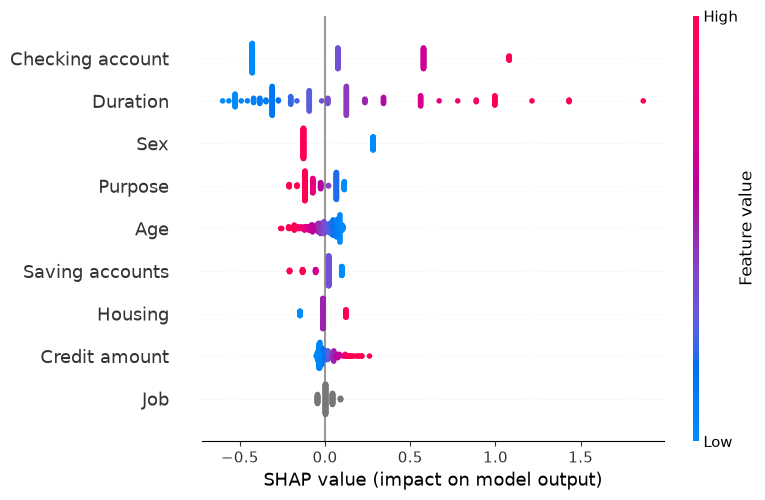

In [78]:
shap.summary_plot(shap_values, X_test)

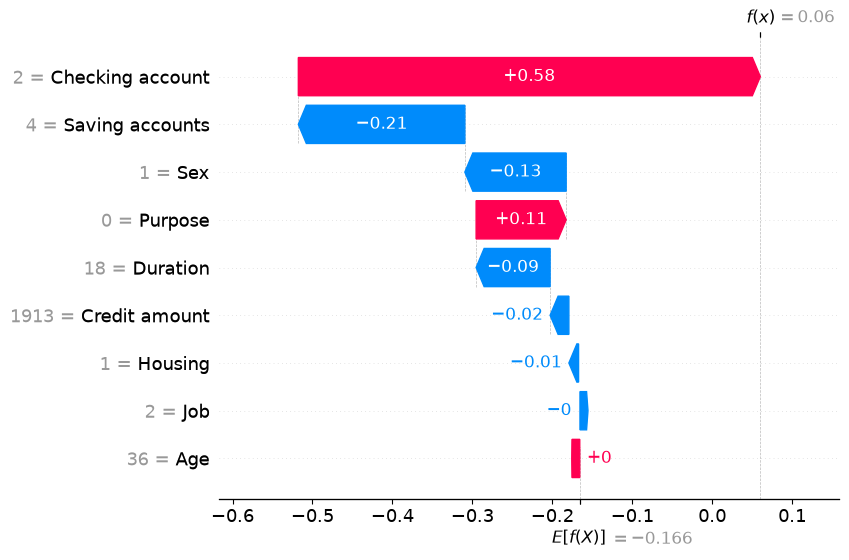

In [79]:
shap.plots.waterfall(shap_values[0])

In [80]:
# Confusion matrix by group
from sklearn.metrics import confusion_matrix

for group in ['male', 'female']:
    mask = sex_test == group
    print(f"\n--- {group} ---")
    print(confusion_matrix(y_test[mask], y_pred[mask]))


--- male ---
[[70 29]
 [19 21]]

--- female ---
[[20 21]
 [ 2 18]]


In [81]:
age_test = df.loc[X_test.index, 'Age']
age_group_test = pd.cut(age_test, bins=[0, 25, 40, 60, 100], labels=['young', 'adult', 'middle_age', 'senior'])

dpd_age = demographic_parity_difference(y_test, y_pred, sensitive_features=age_group_test)
eod_age = equalized_odds_difference(y_test, y_pred, sensitive_features=age_group_test)
print("Demographic Parity Difference (Age):", dpd_age)
print("Equalized Odds Difference (Age):", eod_age)

mf_age = MetricFrame(metrics=accuracy_score, y_true=y_test, y_pred=y_pred, sensitive_features=age_group_test)
print(mf_age.by_group)

Demographic Parity Difference (Age): 0.4825174825174825
Equalized Odds Difference (Age): 0.85
Age
adult         0.619565
middle_age    0.627451
senior        0.769231
young         0.681818
Name: accuracy_score, dtype: float64


In [82]:
X_train_fair = X_train.drop(columns=['Sex'])
X_test_fair = X_test.drop(columns=['Sex'])

model_fair = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_fair.fit(X_train_fair, y_train)

y_pred_fair = model_fair.predict(X_test_fair)

print(classification_report(y_test, y_pred_fair))

dpd_fair = demographic_parity_difference(y_test, y_pred_fair, sensitive_features=sex_test)
eod_fair = equalized_odds_difference(y_test, y_pred_fair, sensitive_features=sex_test)
print("Demographic Parity Difference (Sex) after removal:", dpd_fair)
print("Equalized Odds Difference (Sex) after removal:", eod_fair)

C:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.78      0.61      0.69       140
           1       0.40      0.60      0.48        60

    accuracy                           0.61       200
   macro avg       0.59      0.61      0.58       200
weighted avg       0.67      0.61      0.63       200

Demographic Parity Difference (Sex) after removal: 0.01297322797499706
Equalized Odds Difference (Sex) after removal: 0.07500000000000007


In [84]:
# 1. Predictions + actuals + sensitive attributes (row-level, for Power BI to slice/dice)
results_df = X_test.copy()
results_df['Sex'] = sex_test.values
results_df['Age'] = age_test.values
results_df['Age_group'] = age_group_test.values
results_df['Actual_Risk'] = y_test.values
results_df['Predicted_Risk'] = y_pred_fair  # or y_pred, whichever model you're reporting
results_df['Predicted_Proba'] = model_fair.predict_proba(X_test_fair_scaled)[:, 1]
results_df['Correct'] = (results_df['Actual_Risk'] == results_df['Predicted_Risk']).astype(int)

results_df.to_csv('model_results.csv', index=False)

# 2. Fairness metrics summary table (one row per group per metric)
fairness_summary = pd.DataFrame({
    'Group_Type': ['Sex', 'Sex', 'Age', 'Age'],
    'Metric': ['Demographic Parity Diff', 'Equalized Odds Diff', 'Demographic Parity Diff', 'Equalized Odds Diff'],
    'Before_Mitigation': [0.28, 0.375, 0.48, 0.85],
    'After_Mitigation': [0.013, 0.075, None, None]  # fill in Age after you rerun
})
fairness_summary.to_csv('fairness_summary.csv', index=False)

# 3. Accuracy by group (already have this from mf.by_group / mf_age.by_group)
accuracy_by_group = pd.concat([
    mf.by_group.reset_index().assign(Group_Type='Sex').rename(columns={'Sex':'Group', 'accuracy_score':'Accuracy'}),
    mf_age.by_group.reset_index().assign(Group_Type='Age').rename(columns={'Age':'Group', 'accuracy_score':'Accuracy'})
])
accuracy_by_group.to_csv('accuracy_by_group.csv', index=False)

In [85]:
fairness_metrics = pd.DataFrame({
    "Metric": [
        "Demographic Parity Difference",
        "Equalized Odds Difference",
        "Female Accuracy",
        "Male Accuracy"
    ],
    "Value": [
        0.279632,
        0.375000,
        0.622951,
        0.654676
    ]
})

fairness_metrics.to_csv("fairness_metrics.csv", index=False)

In [86]:
import os
print(os.getcwd())

C:\Users\ANTARA BASAK


In [87]:
X_train_fair_age = X_train.drop(columns=['Age'])
X_test_fair_age = X_test.drop(columns=['Age'])

# Scale (same as we did for Sex, avoids convergence warning)
from sklearn.preprocessing import StandardScaler
scaler_age = StandardScaler()
X_train_fair_age_scaled = scaler_age.fit_transform(X_train_fair_age)
X_test_fair_age_scaled = scaler_age.transform(X_test_fair_age)

model_fair_age = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_fair_age.fit(X_train_fair_age_scaled, y_train)

y_pred_fair_age = model_fair_age.predict(X_test_fair_age_scaled)

# Performance check
print(classification_report(y_test, y_pred_fair_age))

# Fairness metrics (Age)
dpd_fair_age = demographic_parity_difference(y_test, y_pred_fair_age, sensitive_features=age_group_test)
eod_fair_age = equalized_odds_difference(y_test, y_pred_fair_age, sensitive_features=age_group_test)

print("Demographic Parity Difference (Age) after removal:", dpd_fair_age)
print("Equalized Odds Difference (Age) after removal:", eod_fair_age)

              precision    recall  f1-score   support

           0       0.79      0.61      0.69       140
           1       0.41      0.63      0.50        60

    accuracy                           0.61       200
   macro avg       0.60      0.62      0.59       200
weighted avg       0.68      0.61      0.63       200

Demographic Parity Difference (Age) after removal: 0.32867132867132864
Equalized Odds Difference (Age) after removal: 0.85


In [88]:
new_rows = pd.DataFrame({
    'Group_Type': ['Age', 'Age'],
    'Metric': ['Demographic Parity Diff', 'Equalized Odds Diff'],
    'Stage': ['After_Mitigation', 'After_Mitigation'],
    'Score': [0.329, 0.85]
})

fairness_summary = pd.read_csv('fairness_summary.csv')  # or however you're managing this
fairness_summary_updated = pd.concat([fairness_summary, new_rows], ignore_index=True)
fairness_summary_updated.to_csv('fairness_summary.csv', index=False)
print(fairness_summary_updated)

  Group_Type                   Metric  Before_Mitigation  After_Mitigation  \
0        Sex  Demographic Parity Diff              0.280             0.013   
1        Sex      Equalized Odds Diff              0.375             0.075   
2        Age  Demographic Parity Diff              0.480               NaN   
3        Age      Equalized Odds Diff              0.850               NaN   
4        Age  Demographic Parity Diff                NaN               NaN   
5        Age      Equalized Odds Diff                NaN               NaN   

              Stage  Score  
0               NaN    NaN  
1               NaN    NaN  
2               NaN    NaN  
3               NaN    NaN  
4  After_Mitigation  0.329  
5  After_Mitigation  0.850  


In [89]:
fairness_summary_long = pd.DataFrame({
    'Group_Type': ['Sex', 'Sex', 'Sex', 'Sex', 'Age', 'Age', 'Age', 'Age'],
    'Metric': [
        'Demographic Parity Diff', 'Demographic Parity Diff',
        'Equalized Odds Diff', 'Equalized Odds Diff',
        'Demographic Parity Diff', 'Demographic Parity Diff',
        'Equalized Odds Diff', 'Equalized Odds Diff'
    ],
    'Stage': [
        'Before_Mitigation', 'After_Mitigation',
        'Before_Mitigation', 'After_Mitigation',
        'Before_Mitigation', 'After_Mitigation',
        'Before_Mitigation', 'After_Mitigation'
    ],
    'Score': [0.28, 0.013, 0.375, 0.075, 0.48, 0.329, 0.85, 0.85]
})

fairness_summary_long.to_csv('fairness_summary.csv', index=False)
print(fairness_summary_long)

  Group_Type                   Metric              Stage  Score
0        Sex  Demographic Parity Diff  Before_Mitigation  0.280
1        Sex  Demographic Parity Diff   After_Mitigation  0.013
2        Sex      Equalized Odds Diff  Before_Mitigation  0.375
3        Sex      Equalized Odds Diff   After_Mitigation  0.075
4        Age  Demographic Parity Diff  Before_Mitigation  0.480
5        Age  Demographic Parity Diff   After_Mitigation  0.329
6        Age      Equalized Odds Diff  Before_Mitigation  0.850
7        Age      Equalized Odds Diff   After_Mitigation  0.850


In [90]:
import pandas as pd

fairness_summary = pd.DataFrame({
    'Group_Type': ['Sex', 'Sex', 'Age', 'Age'],
    'Metric': ['Demographic Parity Diff', 'Equalized Odds Diff', 'Demographic Parity Diff', 'Equalized Odds Diff'],
    'Before_Mitigation': [0.28, 0.375, 0.48, 0.85],
    'After_Mitigation': [0.013, 0.075, 0.329, 0.85]
})

fairness_summary.to_csv('fairness_summary.csv', index=False)
print(fairness_summary)

  Group_Type                   Metric  Before_Mitigation  After_Mitigation
0        Sex  Demographic Parity Diff              0.280             0.013
1        Sex      Equalized Odds Diff              0.375             0.075
2        Age  Demographic Parity Diff              0.480             0.329
3        Age      Equalized Odds Diff              0.850             0.850


In [91]:
import os; print(os.getcwd())

C:\Users\ANTARA BASAK
